In [1]:
import pandas as pd     
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns   

from sklearn.model_selection import train_test_split    

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier     
from sklearn.ensemble import RandomForestClassifier  
    
from sklearn.metrics import classification_report 
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import confusion_matrix  

In [2]:
data = pd.read_csv("supply_chain_data.csv")
data.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [3]:
data = data.rename(columns={"Reached.on.Time_Y.N": "delayed"})
data = data.drop(columns=["ID"])
data.columns = data.columns.str.lower()

## 1.EDA 

In [4]:
data.shape

(10999, 11)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   warehouse_block      10999 non-null  object
 1   mode_of_shipment     10999 non-null  object
 2   customer_care_calls  10999 non-null  int64 
 3   customer_rating      10999 non-null  int64 
 4   cost_of_the_product  10999 non-null  int64 
 5   prior_purchases      10999 non-null  int64 
 6   product_importance   10999 non-null  object
 7   gender               10999 non-null  object
 8   discount_offered     10999 non-null  int64 
 9   weight_in_gms        10999 non-null  int64 
 10  delayed              10999 non-null  int64 
dtypes: int64(7), object(4)
memory usage: 945.4+ KB


In [6]:
data.isnull().sum()

warehouse_block        0
mode_of_shipment       0
customer_care_calls    0
customer_rating        0
cost_of_the_product    0
prior_purchases        0
product_importance     0
gender                 0
discount_offered       0
weight_in_gms          0
delayed                0
dtype: int64

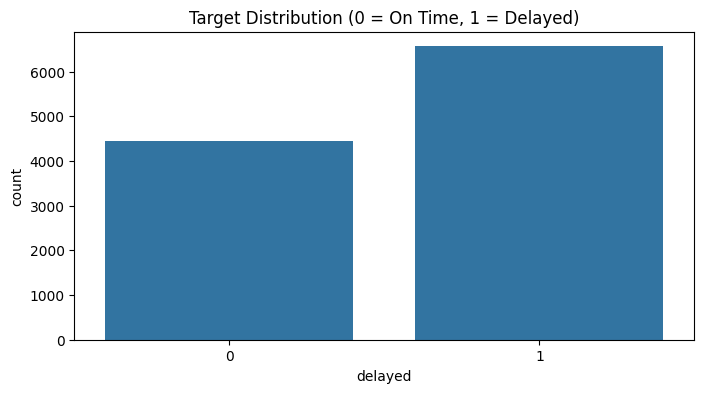

delayed
1    59.669061
0    40.330939
Name: proportion, dtype: float64


In [7]:
# understand target distribution 
plt.figure(figsize=(8,4))
sns.countplot(x="delayed", data=data)
plt.title("Target Distribution (0 = On Time, 1 = Delayed)")
plt.show()

print(data["delayed"].value_counts(normalize=True)*100)

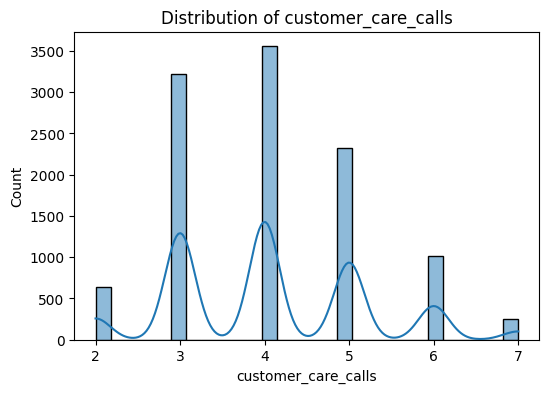

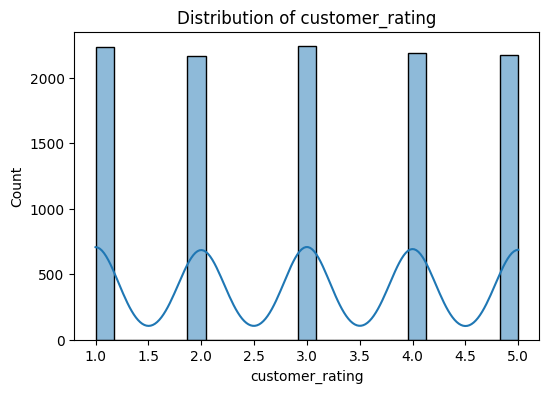

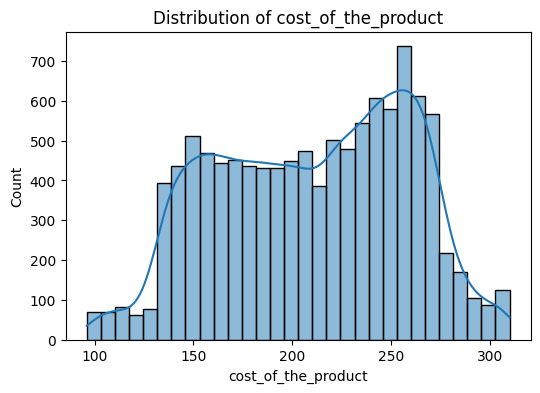

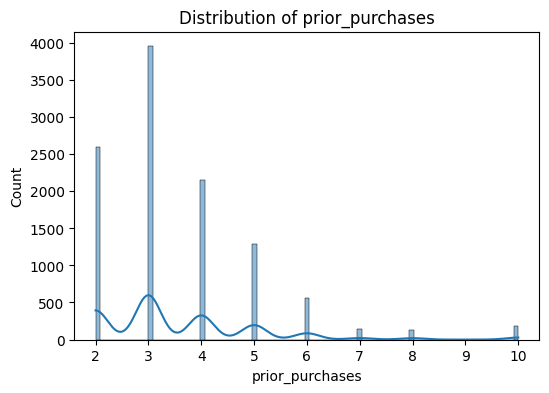

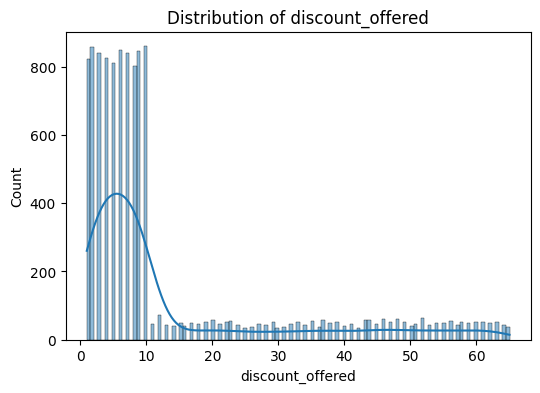

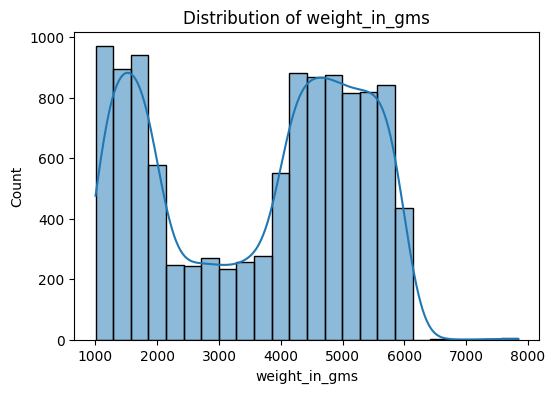

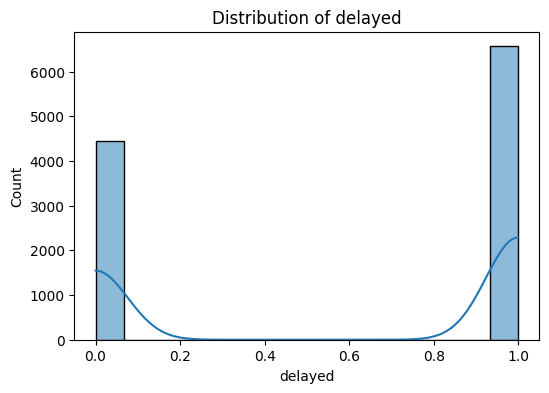

In [8]:
# Numeric Feature Distributions

num_cols = data.select_dtypes(include=["int64","float64"]).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

delayed              0     1
mode_of_shipment            
Flight            39.8  60.2
Road              41.2  58.8
Ship              40.2  59.8


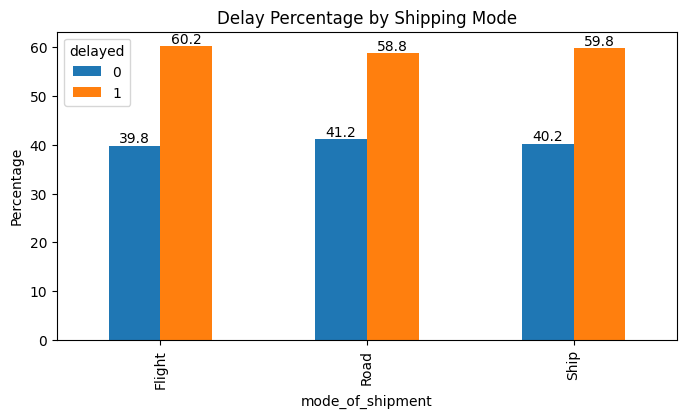

In [9]:
# Delay by shipment mode 

delay_by_mode = (pd.crosstab(
    data["mode_of_shipment"],
    data["delayed"],
    normalize="index"
)*100).round(1)

print(delay_by_mode)

ax = delay_by_mode.plot(kind="bar", stacked=False, figsize=(8,4))
plt.title("Delay Percentage by Shipping Mode")
plt.ylabel("Percentage")
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')
plt.show()


delayed             0     1
warehouse_block            
A                41.4  58.6
B                39.8  60.2
C                40.3  59.7
D                40.2  59.8
F                40.2  59.8


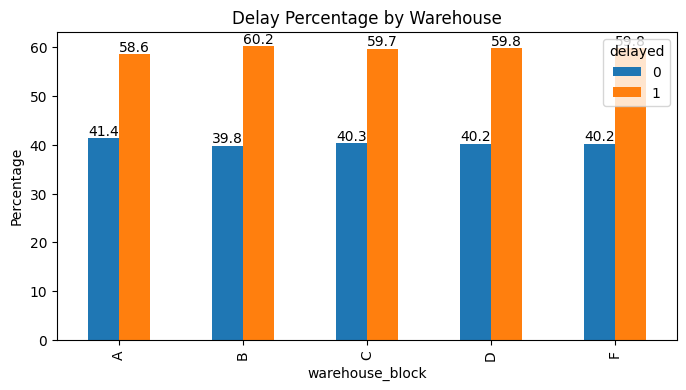

In [10]:
# Delay % by Warehouse
delay_by_warehouse = (pd.crosstab(
    data["warehouse_block"],
    data["delayed"],
    normalize="index"
)*100).round(1)

print(delay_by_warehouse)

ax = delay_by_warehouse.plot(kind="bar",stacked=False,figsize=(8,4))
plt.title("Delay Percentage by Warehouse")
plt.ylabel("Percentage")
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')
plt.show()

delayed                0     1
product_importance            
high                35.0  65.0
low                 40.7  59.3
medium              41.0  59.0


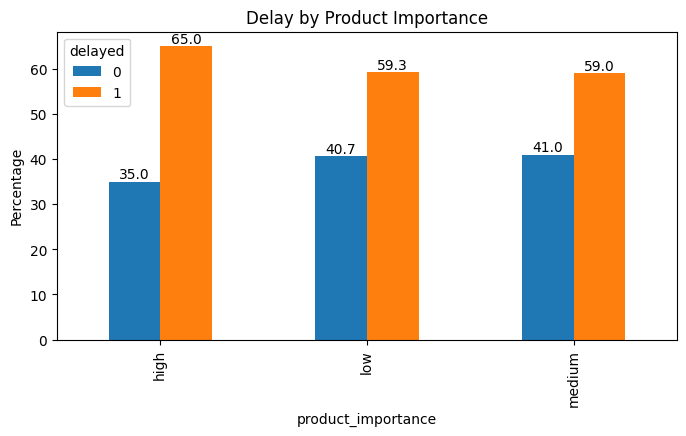

In [11]:
# Delay vs Product Importance
delay_by_importance = (pd.crosstab(
    data["product_importance"],
    data["delayed"],
    normalize="index"
)*100).round(1)

print(delay_by_importance)
ax = delay_by_importance.plot(kind="bar", stacked=False, figsize=(8,4))
plt.title("Delay by Product Importance")
plt.ylabel("Percentage")
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')
    
plt.show()

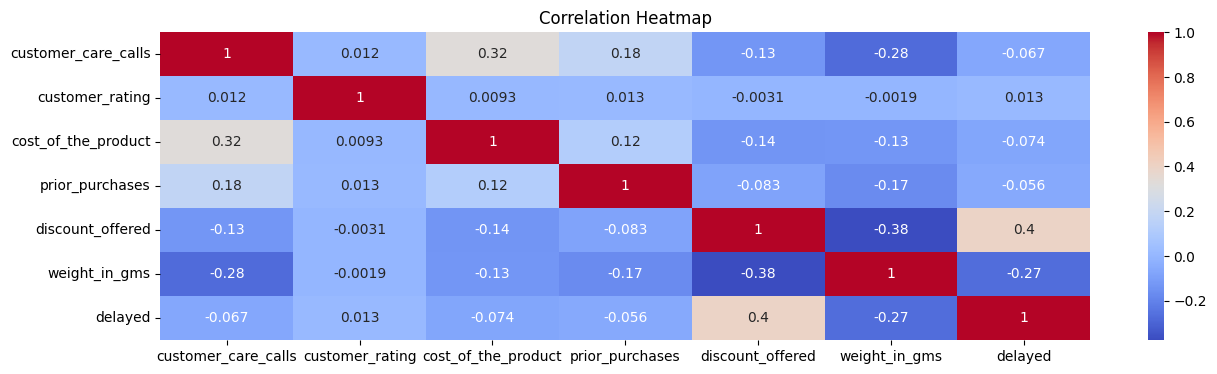

In [12]:
# Correlation between Numeric Features 
plt.figure(figsize=(15,4))
sns.heatmap(
    data.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

---

# 2. Model Development & Evaluation

In [13]:
x = data.iloc[:,:-1]
y = data["delayed"]

In [14]:
x_train , x_test, y_train , y_test = train_test_split(x,y, test_size=0.2,random_state=42, stratify=y)
x_train.shape, x_test.shape

((8799, 10), (2200, 10))

In [15]:
# Separating numeric & categorical columns for pre-processing 

# to get numeric features 
num_col = x.select_dtypes(include="number").columns
print(num_col),print()

# to get categorical features
cat_col = x.select_dtypes(include="object").columns
print(cat_col)

Index(['customer_care_calls', 'customer_rating', 'cost_of_the_product',
       'prior_purchases', 'discount_offered', 'weight_in_gms'],
      dtype='object')

Index(['warehouse_block', 'mode_of_shipment', 'product_importance', 'gender'], dtype='object')


In [16]:
# Transformer to apply Scaling(for logistic regression model) and Onehotencoding

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(transformers=[
    ("numeric",StandardScaler(),num_col),
    ("category",OneHotEncoder(drop="first",handle_unknown="ignore"),cat_col)
]
)

## A. Logistic Regression

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

lgr_pipe = Pipeline(steps=[
    ("preprocessing",preprocessor),
    ("Model",LogisticRegression(class_weight="balanced",max_iter=1000))
])

lgr_pipe.fit(x_train,y_train)

# LGR Model evauluation 

lgr_pred = lgr_pipe.predict(x_test)
print("Logistic Regression Report")
print(classification_report(y_test,lgr_pred))

train_score = lgr_pipe.score(x_train, y_train)
test_score = lgr_pipe.score(x_test, y_test)

print(f"Train score : {train_score*100:.2f}")
print(f"Test score : {test_score*100:.2f}")
print(f"Diff : {(train_score - test_score)*100:.2f}")

Logistic Regression Report
              precision    recall  f1-score   support

           0       0.54      0.84      0.66       887
           1       0.83      0.51      0.63      1313

    accuracy                           0.65      2200
   macro avg       0.68      0.68      0.65      2200
weighted avg       0.71      0.65      0.64      2200

Train score : 65.30
Test score : 64.55
Diff : 0.76


---
---

## B. Decision Tree

In [18]:
from sklearn.tree import DecisionTreeClassifier

dt_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("Model", DecisionTreeClassifier(
        max_depth=5,
        class_weight="balanced",
        random_state=42
    ))
])

dt_pipeline.fit(x_train, y_train)

dt_pred = dt_pipeline.predict(x_test)

print("Decision Tree Report")
print(classification_report(y_test, dt_pred))

Decision Tree Report
              precision    recall  f1-score   support

           0       0.56      0.98      0.71       887
           1       0.97      0.47      0.64      1313

    accuracy                           0.68      2200
   macro avg       0.77      0.73      0.67      2200
weighted avg       0.81      0.68      0.67      2200



---
---

## C. RandomForestClassifier

In [19]:
# Using GridSearchCV to find best Hyper-paramters automatically
from sklearn.model_selection import GridSearchCV

param_grid = {
    "Model__n_estimators": [20, 60, 100],
    "Model__max_features": [0.2, 0.6, 0.75, 1.0],
    "Model__max_depth": [2, 8, None],
    "Model__max_samples": [0.5, 0.75, 1.0]
}

grid_model_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("Model", RandomForestClassifier(random_state=42))
])

rf_grid = GridSearchCV(
    estimator=grid_model_pipe,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring="accuracy"
)

rf_grid.fit(x_train,y_train)
print("Best Params:", rf_grid.best_params_)
print()
print("Train Score:", rf_grid.score(x_train,y_train) * 100)
print("Test Score:", rf_grid.score(x_test, y_test) * 100)
print("Best CV Score:", rf_grid.best_score_ * 100)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Params: {'Model__max_depth': 8, 'Model__max_features': 1.0, 'Model__max_samples': 0.5, 'Model__n_estimators': 100}

Train Score: 72.70144334583475
Test Score: 68.04545454545455
Best CV Score: 68.18962866298


In [20]:
# Best Paramters Using GridSearchCV 
best_params = rf_grid.best_params_

rf_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=best_params["Model__n_estimators"],
        max_depth=best_params["Model__max_depth"],
        max_features=best_params["Model__max_features"],
        max_samples=best_params["Model__max_samples"],
        random_state=42
    ))
])

rf_pipeline.fit(x_train, y_train)

# Predictions
rf_pred = rf_pipeline.predict(x_test)

print("Random Forest Report")
print(classification_report(y_test, rf_pred))

print()
print("Train Score:", rf_pipeline.score(x_train, y_train) * 100)
print("Test Score:", rf_pipeline.score(x_test, y_test) * 100)
print("Best CV Score:", rf_grid.best_score_ * 100)

Random Forest Report
              precision    recall  f1-score   support

           0       0.56      0.94      0.70       887
           1       0.93      0.50      0.65      1313

    accuracy                           0.68      2200
   macro avg       0.74      0.72      0.68      2200
weighted avg       0.78      0.68      0.67      2200


Train Score: 72.70144334583475
Test Score: 68.04545454545455
Best CV Score: 68.18962866298


Top 10 Important Features:
                            Feature  Importance
4         numeric__discount_offered   61.600942
5            numeric__weight_in_gms   15.641247
2      numeric__cost_of_the_product    8.724520
3          numeric__prior_purchases    5.848832
0      numeric__customer_care_calls    2.061576
1          numeric__customer_rating    1.838100
9       category__warehouse_block_F    0.585253
14               category__gender_M    0.569397
11  category__mode_of_shipment_Ship    0.523754
6       category__warehouse_block_B    0.511326


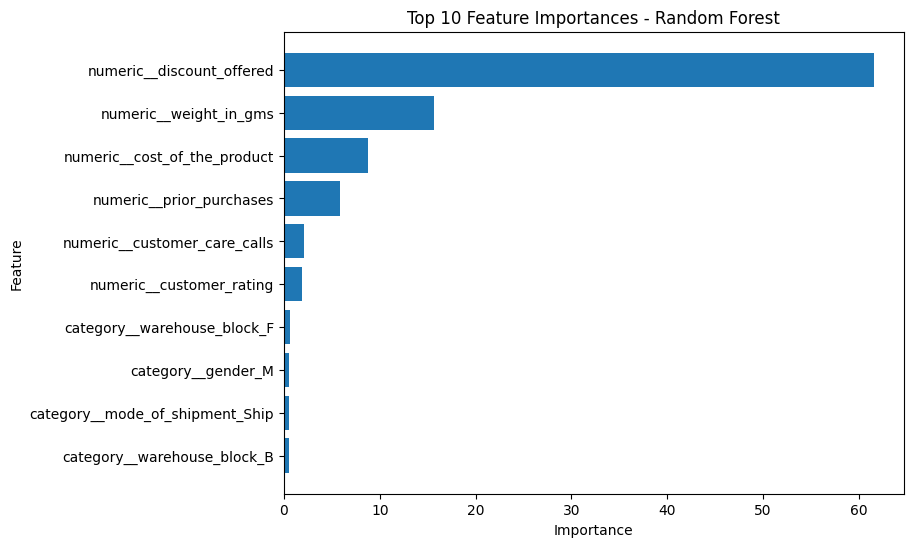

In [21]:
# ===== Feature Importance - Final Step =====

import pandas as pd
import matplotlib.pyplot as plt

# 1. Get best model from GridSearch
best_model = rf_grid.best_estimator_

# 2. Extract feature importances from Random Forest
importances = best_model.named_steps["Model"].feature_importances_*100

# 3. Get feature names after preprocessing (including OneHot encoded names)
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

# 4. Create DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# 5. Sort by importance
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

# 6. Show top features
print("Top 10 Important Features:")
print(feature_importance_df.head(10))

# 7. Plot Top 10 Features
plt.figure(figsize=(8,6))
plt.barh(feature_importance_df["Feature"].head(10),
         feature_importance_df["Importance"].head(10))
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [22]:
# Model Comparison 
from sklearn.metrics import roc_auc_score

# Logiostic regression 
log_pred = lgr_pipe.predict(x_test)
log_prob = lgr_pipe.predict_proba(x_test)[:, 1]
log_acc = accuracy_score(y_test, log_pred)
log_roc = roc_auc_score(y_test, log_prob)

# Decision Tree
dt_pred = dt_pipeline.predict(x_test)
dt_prob = dt_pipeline.predict_proba(x_test)[:, 1]
dt_acc = accuracy_score(y_test, dt_pred)
dt_roc = roc_auc_score(y_test, dt_prob)

# Random Forest 
rf_pred = best_model.predict(x_test)
rf_prob = best_model.predict_proba(x_test)[:, 1]
rf_acc = accuracy_score(y_test, rf_pred)
rf_roc = roc_auc_score(y_test, rf_prob)

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [log_acc, dt_acc, rf_acc],
    "ROC-AUC": [log_roc, dt_roc, rf_roc]
})

comparison_df.sort_values(by="ROC-AUC", ascending=False)

,Model,Accuracy,ROC-AUC
2,Random Forest,0.680455,0.746331
1,Decision Tree,0.678182,0.736475
0,Logistic Regression,0.645455,0.717043


## Final Model Summary

- Compared **Logistic Regression**, **Decision Tree**, and **Random Forest** for delivery delay prediction.
- **Random Forest** achieved the best overall performance:
  - Accuracy: **68.05%**
  - ROC-AUC: **0.746**
  - Train Score: **72.70%**
  - Best Cross-Validation Score: **68.19%**
- **Decision Tree** performance:
  - Accuracy: **67.82%**
  - ROC-AUC: **0.736**
- **Logistic Regression** performance:
  - Accuracy: **64.55%**
  - ROC-AUC: **0.717**
- Tree-based models outperformed Logistic Regression, indicating the presence of non-linear relationships in shipment data.
- Recall for delayed shipments (~50%) suggests moderate detection capability and scope for further improvement.